# Tahoe A549: Bulk Viability vs Single-Cell Transcriptomic Effect

**Goal**: Reproduce + complete Tahoe notebook Section 8 for A549 — correlate GDSC bulk viability with single-cell transcriptomic shift magnitude.

**Datasets**:
- `tahoe_a549_w_emb.h5ad` — 2.3M single cells, 367 drugs, multiple embeddings in obsm
- `GDSC_dataset.csv` — bulk viability (0–1 normalized), Prophet format

**Key differences from Sciplex3 analysis**:
- Single cell line (A549 only) → no cell-line mismatch noise
- 367 drugs → much larger overlap with GDSC
- Multiple pre-computed embeddings available for comparison
- Drug column is `drug_0` (not `pert_compound`)

**Embeddings benchmarked**:
- `AE_10_pretrained`, `AE_32_pretrained`, `AE_128_pretrained` — autoencoder embeddings
- `X_pca` — PCA of raw counts
- `X_scconcept` — scConcept embedding
- `X_scgpt` — scGPT foundation model
- `X_scimilarity`, `X_scimilarity_correct` — scSimilarity embeddings
- `X_state` — scVI latent space
- `raw_hvg` — raw gene expression (HVG subset, PCA from scratch)

## 1. Imports and Setup

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

DATA_PATH   = "/storage/pancellflow/data/tahoe_a549_w_emb.h5ad"
GDSC_PATH   = "/storage/pancellflow/datasets/GDSC_dataset.csv"
RESULTS_DIR = "/storage/pancellflow/results/"

os.makedirs(RESULTS_DIR, exist_ok=True)

N_SAMPLE           = 1500000  # cells to subsample for PCA fitting
N_PCS              = 300     # PCA components on top of each embedding
N_HVG              = 5000   # HVGs for raw gene expression baseline
MAX_CELLS_PER_DRUG = 100000    # cap treated cells per drug
MIN_CELLS          = 10     # minimum cells required per drug

# All obsm embeddings to benchmark + raw gene expression
OBSM_KEYS = [
    "AE_10_pretrained",
    "X_pca",
    "X_scconcept",
    "X_scgpt",
    "X_scimilarity",
    "X_scimilarity_correct",
]

## 2. Load Tahoe A549 and Inspect

In [2]:
adata = ad.read_h5ad(DATA_PATH, backed="r")

print(f"Cells    : {adata.n_obs:,}")
print(f"Genes    : {adata.n_vars:,}")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"obs  cols: {adata.obs.columns.tolist()}")

drugs     = [d for d in adata.obs["drug_0"].unique() if d != "control"]
n_control = (adata.obs["drug_0"] == "control").sum()
print(f"\nDrugs   : {len(drugs)}")
print(f"Control : {n_control:,}")

# Print embedding dimensions
print("\nEmbedding dimensions:")
for key in adata.obsm.keys():
    print(f"  {key}: {adata.obsm[key].shape[1]}d")

Cells    : 2,326,890
Genes    : 62,710
obsm keys: ['AE_10_pretrained', 'AE_128_pretrained', 'AE_32_pretrained', 'X_pca', 'X_scconcept', 'X_scgpt', 'X_scimilarity', 'X_scimilarity_correct', 'X_state']
obs  cols: ['sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'id', 'drugname_drugconc', 'drug', 'INT_ID', 'NUM.SNPS', 'NUM.READS', 'demuxlet_call', 'BEST.GUESS', 'BEST.LLK', 'NEXT.GUESS', 'NEXT.LLK', 'DIFF.LLK.BEST.NEXT', 'BEST.POSTERIOR', 'SNG.POSTERIOR', 'cell_line', 'SNG.BEST.LLK', 'SNG.NEXT.GUESS', 'SNG.NEXT.LLK', 'SNG.ONLY.POSTERIOR', 'DBL.BEST.GUESS', 'DBL.BEST.LLK', 'DIFF.LLK.SNG.DBL', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'cell_line_orig', 'pass_filter', 'cell_name', 'dosage', 'plate', 'pert_compound', 'drug_org', 'drug_0', 'drug_1']

Drugs   : 367
Control : 57,448

Embedding dimensions:
  AE_10_pretrained: 10d
  AE_128_pretrained: 128d
  AE_32_pretrained: 32d
  X

In [5]:
adata

AnnData object with n_obs × n_vars = 2326890 × 62710 backed at '/storage/pancellflow/data/tahoe_a549_w_emb.h5ad'
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'id', 'drugname_drugconc', 'drug', 'INT_ID', 'NUM.SNPS', 'NUM.READS', 'demuxlet_call', 'BEST.GUESS', 'BEST.LLK', 'NEXT.GUESS', 'NEXT.LLK', 'DIFF.LLK.BEST.NEXT', 'BEST.POSTERIOR', 'SNG.POSTERIOR', 'cell_line', 'SNG.BEST.LLK', 'SNG.NEXT.GUESS', 'SNG.NEXT.LLK', 'SNG.ONLY.POSTERIOR', 'DBL.BEST.GUESS', 'DBL.BEST.LLK', 'DIFF.LLK.SNG.DBL', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'cell_line_orig', 'pass_filter', 'cell_name', 'dosage', 'plate', 'pert_compound', 'drug_org', 'drug_0', 'drug_1'
    uns: 'AE_pretrained_hvg_var_names', 'X_pca_loadings', 'X_pca_variance', 'X_pca_variance_ratio', 'cell_line_ccle_embedding_dim', 'cell_line_ccle_embeddings', 'cell_line_embedding_dim', 'cell_line_embeddings', 'drug_0_emb

## 3. Precompute HVG PCA for Raw Gene Expression Baseline

This is the only embedding that requires preprocessing. All obsm embeddings are used directly.

In [ ]:
rng = np.random.default_rng(42)
idx = rng.choice(adata.n_obs, N_SAMPLE, replace=False)

# Get HVGs
adata_sub = adata[idx].copy()
sc.pp.normalize_total(adata_sub)
sc.pp.log1p(adata_sub)
sc.pp.highly_variable_genes(adata_sub, n_top_genes=N_HVG)
hvg_genes = adata_sub.var_names[adata_sub.var["highly_variable"]]
del adata_sub

# Fit PCA on HVG subset
X_hvg = adata[idx][:, hvg_genes].X
X_hvg = X_hvg.toarray() if sp.issparse(X_hvg) else np.array(X_hvg, dtype=np.float32)
pca_hvg = PCA(n_components=N_PCS, random_state=42)
pca_hvg.fit(X_hvg)
del X_hvg

print(f"HVGs: {len(hvg_genes)} | Explained variance: {pca_hvg.explained_variance_ratio_.sum():.1%} in {N_PCS} PCs")

## 4. Compute Drug Effects for All Embeddings

For each embedding, fit PCA on a subsample, then compute per-drug pseudobulk mean shift.

In [7]:
# Precompute control and drug indices once
rng = np.random.default_rng(42)
idx = rng.choice(adata.n_obs, N_SAMPLE, replace=False)
ctrl_idx_all = np.where(adata.obs["drug_0"].values == "control")[0]
if len(ctrl_idx_all) > 15000:
    ctrl_idx = rng.choice(ctrl_idx_all, 15000, replace=False)
else:
    ctrl_idx = ctrl_idx_all

drug_indices = {}
for drug in drugs:
    didx = np.where(adata.obs["drug_0"].values == drug)[0]
    if len(didx) >= MIN_CELLS:
        if len(didx) > MAX_CELLS_PER_DRUG:
            didx = rng.choice(didx, MAX_CELLS_PER_DRUG, replace=False)
        drug_indices[drug] = didx

print(f"Control cells : {len(ctrl_idx):,}")
print(f"Valid drugs   : {len(drug_indices)}")

Control cells : 15,000
Valid drugs   : 367


In [8]:
def compute_effects_for_embedding(emb_matrix, pca_model=None):
    if pca_model is not None:
        ctrl_mean = pca_model.transform(emb_matrix[ctrl_idx].astype(np.float32)).mean(axis=0)
    else:
        ctrl_mean = emb_matrix[ctrl_idx].astype(np.float32).mean(axis=0)

    records = []
    for drug, didx in drug_indices.items():
        if pca_model is not None:
            drug_mean = pca_model.transform(emb_matrix[didx].astype(np.float32)).mean(axis=0)
        else:
            drug_mean = emb_matrix[didx].astype(np.float32).mean(axis=0)
        euclidean = np.linalg.norm(drug_mean - ctrl_mean)
        records.append({"drug": drug, "euclidean_dist": euclidean})

    df = pd.DataFrame(records)
    df["drug_norm"] = df["drug"].str.lower().str.strip()
    return df


# Run for each embedding
all_results = {}  # {emb_key: DataFrame}

for key in OBSM_KEYS:
    print(f"\nProcessing: {key}")

    if key == "raw_hvg":
        # Use pre-computed HVG PCA
        # Build full HVG matrix for all needed cells
        needed_idx = np.concatenate([ctrl_idx] + list(drug_indices.values()))
        needed_idx = np.unique(needed_idx)
        X_full = adata[needed_idx][:, hvg_genes].X
        X_full = X_full.toarray() if sp.issparse(X_full) else np.array(X_full, dtype=np.float32)

        # Remap indices to the needed_idx subset
        idx_map = {orig: new for new, orig in enumerate(needed_idx)}
        ctrl_remapped = np.array([idx_map[i] for i in ctrl_idx])
        drug_idx_remapped = {d: np.array([idx_map[i] for i in didx])
                             for d, didx in drug_indices.items()}

        ctrl_mean_pca = pca_hvg.transform(X_full[ctrl_remapped]).mean(axis=0)
        records = []
        for drug, didx in drug_idx_remapped.items():
            drug_mean_pca = pca_hvg.transform(X_full[didx]).mean(axis=0)
            euclidean = np.linalg.norm(drug_mean_pca - ctrl_mean_pca)
            records.append({"drug": drug, "euclidean_dist": euclidean})
        df = pd.DataFrame(records)
        df["drug_norm"] = df["drug"].str.lower().str.strip()
        del X_full

    else:
        if key not in adata.obsm:
            print(f"  Skipping {key} — not found in obsm")
            continue

        emb = np.array(adata.obsm[key], dtype=np.float32)
        print(f"  Shape: {emb[idx].shape}")

        if key == "X_pca":
            # already in PCA space
            df = compute_effects_for_embedding(emb, pca_model=None)
        elif emb.shape[1] <= N_PCS:
            # embedding dim smaller than n_pcs — use as is
            print(f"  Dim {emb.shape[1]} <= N_PCS {N_PCS}, skipping PCA")
            df = compute_effects_for_embedding(emb, pca_model=None)
        else:
            pca_emb = PCA(n_components=N_PCS, random_state=42)
            pca_emb.fit(emb[idx])
            print(f"  Explained variance: {pca_emb.explained_variance_ratio_.sum():.1%}")
            df = compute_effects_for_embedding(emb, pca_emb)
        del emb

    all_results[key] = df
    gc.collect()
    print(f"  Done — {len(df)} drugs")


Processing: AE_10_pretrained
  Shape: (1500000, 10)
  Dim 10 <= N_PCS 300, skipping PCA
  Done — 367 drugs

Processing: X_pca
  Shape: (1500000, 100)
  Done — 367 drugs

Processing: X_scconcept
  Shape: (1500000, 512)
  Explained variance: 100.0%
  Done — 367 drugs

Processing: X_scgpt
  Shape: (1500000, 512)
  Explained variance: 99.7%
  Done — 367 drugs

Processing: X_scimilarity
  Shape: (1500000, 128)
  Dim 128 <= N_PCS 300, skipping PCA
  Done — 367 drugs

Processing: X_scimilarity_correct
  Shape: (1500000, 128)
  Dim 128 <= N_PCS 300, skipping PCA
  Done — 367 drugs


In [6]:
del adata
gc.collect()

0

## 5. Load GDSC and Match

In [9]:
gdsc = pd.read_csv(GDSC_PATH)
gdsc["drug_norm"]      = gdsc["iv_name"].str.lower().str.strip()
gdsc["cell_line_norm"] = gdsc["cell_line"].str.lower().str.strip()

gdsc_a549 = gdsc[gdsc["cell_line_norm"].str.contains("a549", na=False)]
print(f"GDSC A549 rows : {len(gdsc_a549):,} | drugs : {gdsc_a549['drug_norm'].nunique()}")

gdsc_viability = (
    gdsc_a549.groupby("drug_norm")["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "mean_viability"})
)

GDSC A549 rows : 281 | drugs : 272


## 6. Correlate Each Embedding vs GDSC Viability

In [10]:
correlation_results = []

for key, df in all_results.items():
    merged = df.merge(gdsc_viability, on="drug_norm", how="inner").dropna()
    if len(merged) < 5:
        print(f"{key}: too few matched drugs ({len(merged)})")
        continue
    r, p = stats.spearmanr(merged["euclidean_dist"], merged["mean_viability"])
    correlation_results.append({
        "embedding"    : key,
        "spearman_r"   : r,
        "p_value"      : p,
        "n_drugs"      : len(merged),
    })
    print(f"{key:30s}: r={r:.3f}  p={p:.4f}  n={len(merged)}")

corr_df = pd.DataFrame(correlation_results).sort_values("spearman_r")
corr_df

AE_10_pretrained              : r=-0.314  p=0.1041  n=28
X_pca                         : r=-0.487  p=0.0086  n=28
X_scconcept                   : r=-0.119  p=0.5453  n=28
X_scgpt                       : r=-0.093  p=0.6397  n=28
X_scimilarity                 : r=-0.239  p=0.2213  n=28
X_scimilarity_correct         : r=-0.239  p=0.2213  n=28


,embedding,spearman_r,p_value,n_drugs
1,X_pca,-0.486590,0.008647,28
0,AE_10_pretrained,-0.313629,0.104118,28
4,X_scimilarity,-0.238643,0.221341,28
5,X_scimilarity_correct,-0.238643,0.221341,28
2,X_scconcept,-0.119321,0.545332,28
3,X_scgpt,-0.092501,0.639669,28


In [30]:
merged

,drug,euclidean_dist,drug_norm,mean_viability
0,crizotinib,0.109986,crizotinib,0.462322
1,Dinaciclib,0.285653,dinaciclib,0.226512
2,Cytarabine,0.076240,cytarabine,0.333383
3,Afatinib,0.026637,afatinib,0.431084
4,Erlotinib,0.085852,erlotinib,0.481738
5,Fulvestrant,0.080683,fulvestrant,0.522525
6,Trametinib,0.063501,trametinib,0.247887
7,Methotrexate,0.074616,methotrexate,0.367756
8,5-Fluorouracil,0.088306,5-fluorouracil,0.486224
9,5-Azacytidine,0.077523,5-azacytidine,0.469401


## 7. Summary Plot: Embedding Comparison

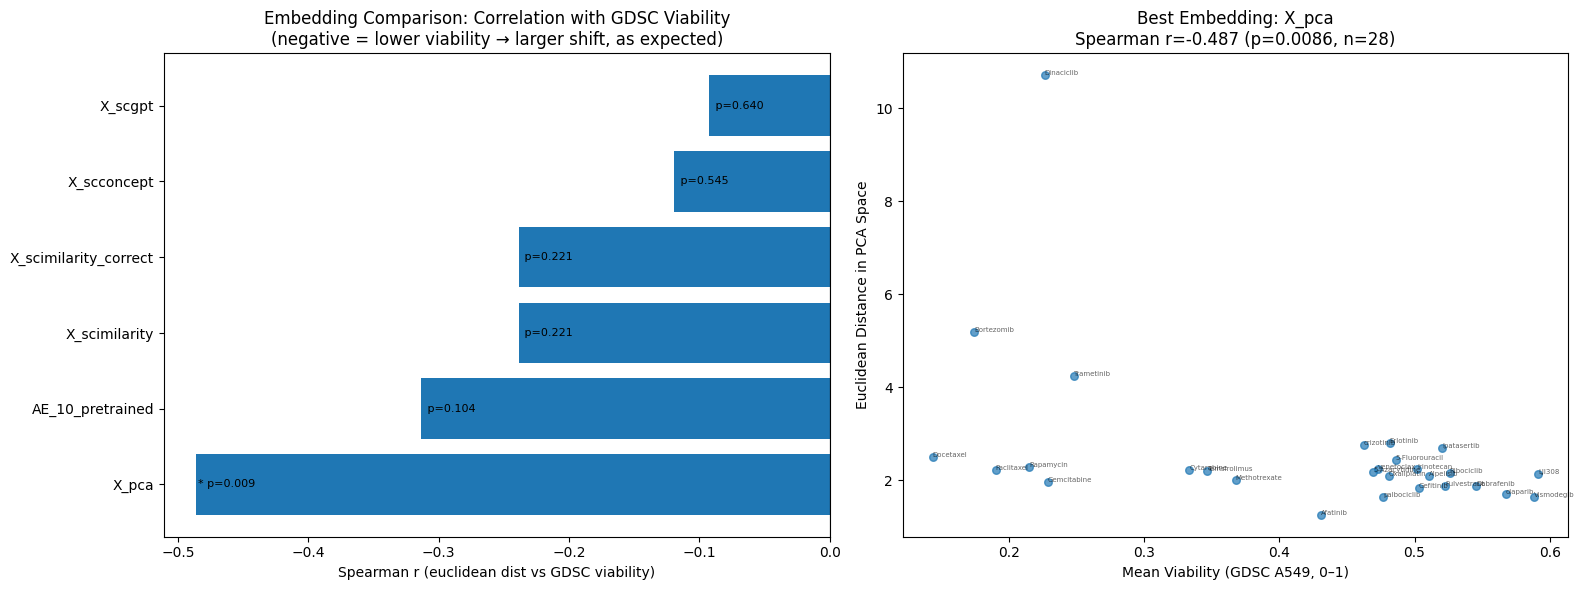

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of Spearman r per embedding
ax = axes[0]
colors = ["#d62728" if r > 0 else "#1f77b4" for r in corr_df["spearman_r"]]
bars = ax.barh(corr_df["embedding"], corr_df["spearman_r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman r (euclidean dist vs GDSC viability)")
ax.set_title("Embedding Comparison: Correlation with GDSC Viability\n"
             "(negative = lower viability → larger shift, as expected)")

# Annotate with p-value significance
for bar, (_, row) in zip(bars, corr_df.iterrows()):
    sig = "*" if row["p_value"] < 0.05 else ""
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{sig} p={row['p_value']:.3f}", va="center", fontsize=8)

# Scatter for best embedding
ax = axes[1]
best_key = corr_df.iloc[0]["embedding"]  # most negative r
best_df  = all_results[best_key].merge(gdsc_viability, on="drug_norm", how="inner").dropna()
r_best, p_best = stats.spearmanr(best_df["euclidean_dist"], best_df["mean_viability"])

ax.scatter(best_df["mean_viability"], best_df["euclidean_dist"], alpha=0.7, s=30)
for _, row in best_df.iterrows():
    ax.annotate(row["drug"], (row["mean_viability"], row["euclidean_dist"]),
                fontsize=5, alpha=0.6)
ax.set_xlabel("Mean Viability (GDSC A549, 0–1)")
ax.set_ylabel("Euclidean Distance in PCA Space")
ax.set_title(f"Best Embedding: {best_key}\nSpearman r={r_best:.3f} (p={p_best:.4f}, n={len(best_df)})")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tahoe_a549_embedding_comparison.png"), dpi=150)
plt.show()

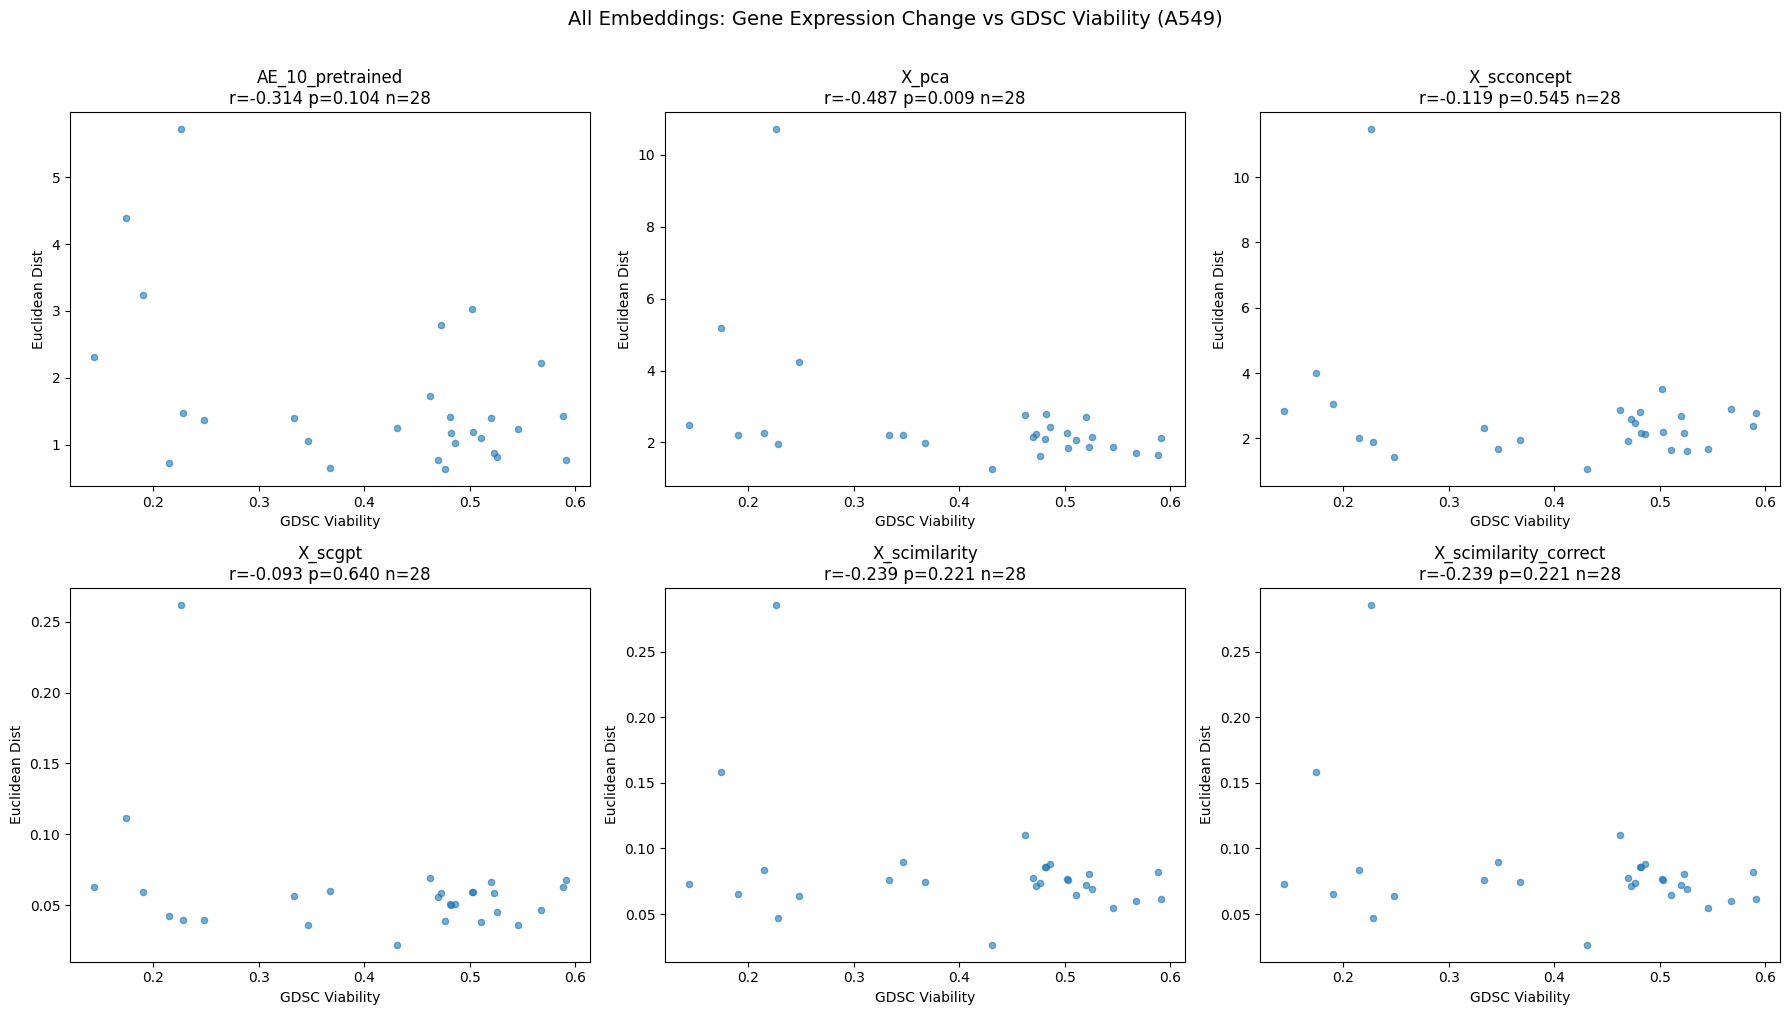

In [11]:
# Individual scatter per embedding
n = len(all_results)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, (key, df) in zip(axes, all_results.items()):
    merged = df.merge(gdsc_viability, on="drug_norm", how="inner").dropna()
    if len(merged) < 5:
        ax.set_visible(False)
        continue
    r, p = stats.spearmanr(merged["euclidean_dist"], merged["mean_viability"])
    ax.scatter(merged["mean_viability"], merged["euclidean_dist"], alpha=0.6, s=20)
    ax.set_xlabel("GDSC Viability")
    ax.set_ylabel("Euclidean Dist")
    ax.set_title(f"{key}\nr={r:.3f} p={p:.3f} n={len(merged)}")

# Hide unused axes
for ax in axes[len(all_results):]:
    ax.set_visible(False)

plt.suptitle("All Embeddings: Gene Expression Change vs GDSC Viability (A549)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tahoe_a549_all_embeddings_scatter.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("=== FINAL SUMMARY ===")
print(f"{'Embedding':<30} {'Spearman r':>12} {'p-value':>10} {'n drugs':>8}")
print("-" * 65)
for _, row in corr_df.sort_values("spearman_r").iterrows():
    sig = " *" if row["p_value"] < 0.05 else "  "
    print(f"{row['embedding']:<30} {row['spearman_r']:>12.3f} {row['p_value']:>10.4f} {int(row['n_drugs']):>8}{sig}")

print(f"\nBest embedding: {corr_df.iloc[0]['embedding']} (r={corr_df.iloc[0]['spearman_r']:.3f})")